#   Conditional Workflow in LangGraph
`This is qdratical conditional workflow without LLM`

In [55]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [56]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    descriminant: float
    result: float
    

In [57]:
def show_equation(state: QuadState):
    equation = f"{state['a']}x2 + {state['b']}x + {state['c']}"
    print(equation)
    return {"equation": equation}

In [58]:
def calculate_descriminant(state: QuadState):
    descriminant = state['b']**2 - (4*state['a']*state['c'])
    print(descriminant)
    return {'descriminant': descriminant}

In [59]:
def reel_roots(state: QuadState):
    root1 = (-state['b'] + state['descriminant']**0.5)/ (2*state['a'])
    root2 = (-state['b'] - state['descriminant']**0.5)/ (2*state['a'])
    result = f"The roots are the {root1} and {root2}"
    return {'result': result}

In [60]:
def repeated_roots(state: QuadState):
    root = -state['b']/ (2*state['a'])
    result = f"Onlu repeating root is : {root}"
    return {'result': result}

In [61]:
def no_reel_roots(state: QuadState):
    result = f"No real roots"
    return {'result': result}

In [62]:
def check_condition(state: QuadState) -> Literal["reel_roots", "repeated_roots", "no_reel_roots"]:
    if state["descriminant"] > 0:
        return "reel_roots"
    elif state["descriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_reel_roots"


In [63]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_descriminant', calculate_descriminant)
graph.add_node('reel_roots', reel_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_reel_roots', no_reel_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_descriminant')

graph.add_conditional_edges("calculate_descriminant", check_condition)

graph.add_edge('reel_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_reel_roots', END)

workflow = graph.compile()

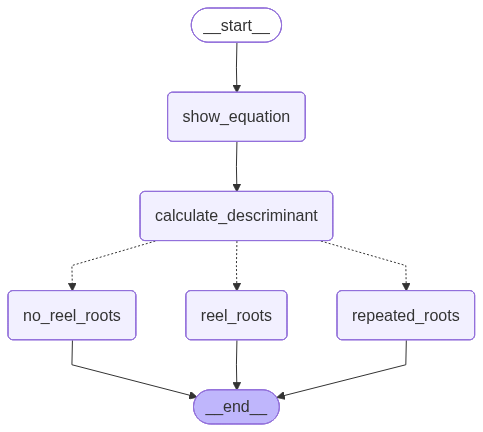

In [65]:
graph.compile()

In [64]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow.invoke(initial_state)

4x2 + -5x + -4
89


{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2 + -5x + -4',
 'descriminant': 89,
 'result': 'The roots are the 1.8042476415070754 and -0.5542476415070754'}